In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned.csv")
df.head(5)

,subject,age,sex,label,transcript,clean_transcripts
0,2,58.0,female,Control,PAR: the scene is <in the> in the kitchen . 3...,the scene is in the in the kitchen . the mothe...
1,2,59.0,female,Control,INV: what do you see going on in that picture ...,oh I see the sink is running over . I see the ...
2,2,60.0,female,Control,INV: look at the picture and tell me everythin...,um a boy and a girl are in the kitchen with th...
3,2,61.0,female,Control,INV: look at that picture and I want you to te...,okay . it was summertime and mother and the ch...
4,6,72.0,male,Control,PAR: &=clears:throat wait (un)til I put my gla...,clearsthroat wait until I put my glasses on . ...


In [2]:
df['label'].value_counts()

label
Control       243
ProbableAD    234
MCI            42
PossibleAD     21
Vascular        5
Memory          3
Other           1
Name: count, dtype: int64

In [3]:
import pandas as pd
df['label'] = df['label'].replace({
    'ProbableAD': 'AD',
    'PossibleAD': 'AD'
})
df = df[~df['label'].isin(['Vascular', 'Memory', 'Other'])]
print(df['label'].value_counts())



label
AD         255
Control    243
MCI         42
Name: count, dtype: int64


In [17]:
df

,subject,age,sex,label,transcript,clean_transcripts
0,2,58.0,female,Control,PAR: the scene is <in the> in the kitchen . 3...,the scene is in the in the kitchen . the mothe...
1,2,59.0,female,Control,INV: what do you see going on in that picture ...,oh I see the sink is running over . I see the ...
2,2,60.0,female,Control,INV: look at the picture and tell me everythin...,um a boy and a girl are in the kitchen with th...
3,2,61.0,female,Control,INV: look at that picture and I want you to te...,okay . it was summertime and mother and the ch...
4,6,72.0,male,Control,PAR: &=clears:throat wait (un)til I put my gla...,clearsthroat wait until I put my glasses on . ...
...,...,...,...,...,...,...
546,703,73.0,female,AD,INV: that's happening in that picture . 470_1...,"uh well , heres the child reaching up but hes ..."
548,705,71.0,female,AD,INV: picture okay ? ▶ PAR: mhm . ▶ INV: can yo...,"mhm . well , this one is in the cookie jar . a..."
549,707,74.0,female,AD,INV: I'd like for you to take a look at this p...,hm . the little boy is on the stool which is t...
550,711,77.0,male,AD,INV: I want you to take a look at this picture...,"oh , you want me to tell you . the mother and ..."


         count        mean        std   min   25%    50%    75%    max
label                                                                 
AD       235.0  118.476596  64.941019  23.0  73.0  105.0  140.0  433.0
Control  183.0  130.377049  68.201100  44.0  86.0  114.0  163.5  556.0


C:\Users\lclai\AppData\Local\Temp\ipykernel_23152\3332477597.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='text_length', data=df_filtered, palette='pastel')


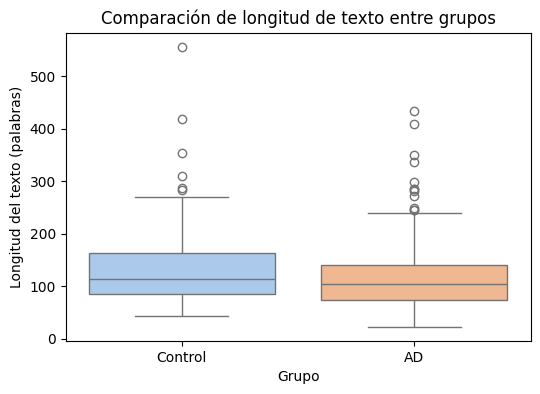

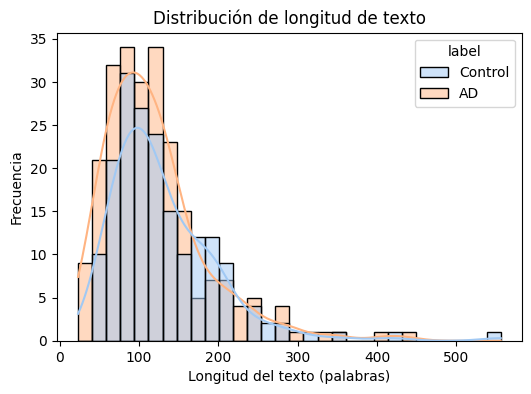

T-test: t = 1.807, p = 7.152e-02
❌ No hay diferencia estadísticamente significativa entre grupos.


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Si tu dataframe se llama df
# Asegúrate de que la columna 'clean_transcripts' no tenga nulos
df = df.dropna(subset=['clean_transcripts'])

# 🔢 Calculamos la longitud de cada transcript (en palabras)
df['text_length'] = df['clean_transcripts'].apply(lambda x: len(x.split()))

# ✨ Solo consideramos los grupos Control y AD
df_filtered = df[df['label'].isin(['Control', 'AD'])]

# 📈 Estadísticas descriptivas
stats = df_filtered.groupby('label')['text_length'].describe()
print(stats)

# 🎨 Boxplot para comparar visualmente
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='text_length', data=df_filtered, palette='pastel')
plt.title('Comparación de longitud de texto entre grupos')
plt.xlabel('Grupo')
plt.ylabel('Longitud del texto (palabras)')
plt.show()

# 📊 Histograma
plt.figure(figsize=(6,4))
sns.histplot(data=df_filtered, x='text_length', hue='label', kde=True, bins=30, palette='pastel')
plt.title('Distribución de longitud de texto')
plt.xlabel('Longitud del texto (palabras)')
plt.ylabel('Frecuencia')
plt.show()

# 🧠 Test estadístico (t-test independiente)
control_lengths = df_filtered[df_filtered['label'] == 'Control']['text_length']
ad_lengths = df_filtered[df_filtered['label'] == 'AD']['text_length']

t_stat, p_value = ttest_ind(control_lengths, ad_lengths, equal_var=False)
print(f"T-test: t = {t_stat:.3f}, p = {p_value:.3e}")

if p_value < 0.05:
    print("✅ Diferencia estadísticamente significativa entre grupos.")
else:
    print("❌ No hay diferencia estadísticamente significativa entre grupos.")


Mapeo de etiquetas: {'AD': 0, 'Control': 1, 'MCI': 2}

🔹 Entrenando Random Forest...

✅ Mejor configuración Random Forest: {'model__max_depth': 10, 'model__n_estimators': 200, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.662     0.915     0.768        47
     Control      0.840     0.568     0.677        37
         MCI      0.000     0.000     0.000         6

    accuracy                          0.711        90
   macro avg      0.501     0.494     0.482        90
weighted avg      0.691     0.711     0.679        90



c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

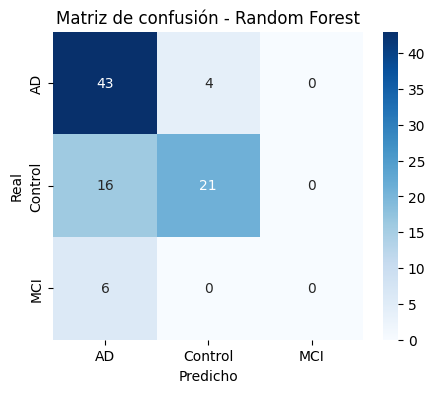


🔹 Entrenando XGBoost...

✅ Mejor configuración XGBoost: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 300, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.707     0.872     0.781        47
     Control      0.750     0.649     0.696        37
         MCI      0.000     0.000     0.000         6

    accuracy                          0.722        90
   macro avg      0.486     0.507     0.492        90
weighted avg      0.677     0.722     0.694        90



c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

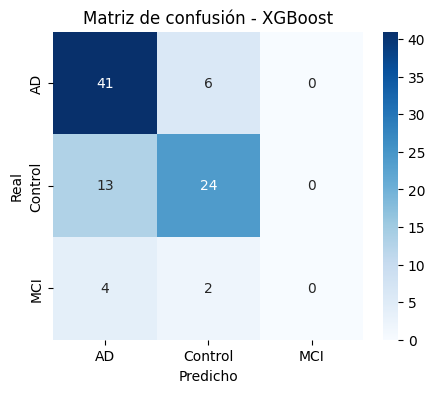


🔹 Entrenando Logistic Regression...

✅ Mejor configuración Logistic Regression: {'model__C': 1, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.729     0.915     0.811        47
     Control      0.839     0.703     0.765        37
         MCI      0.000     0.000     0.000         6

    accuracy                          0.767        90
   macro avg      0.523     0.539     0.525        90
weighted avg      0.725     0.767     0.738        90



c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

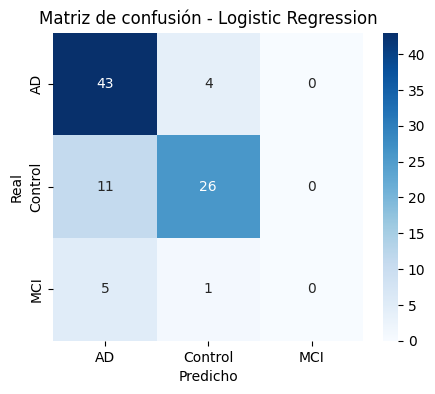

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

# ======================
# 🔹 1. Preparar dataset
# ======================
df = df.dropna(subset=['clean_transcripts', 'label'])
df = df[df['label'].isin(['Control', 'AD', 'MCI'])]

# 🔹 Codificar etiquetas a números
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['label'])
print("Mapeo de etiquetas:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_transcripts']
y = df['label_num']

# ======================
# 🔹 2. Train/test split
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================
# 🔹 3. Modelos
# ======================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric='mlogloss'
    ),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

param_grids = {
    "Random Forest": {
        'tfidf__max_features': [3000],
        'model__n_estimators': [200],
        'model__max_depth': [10, 20, None]
    },
    "XGBoost": {
        'tfidf__max_features': [3000],
        'model__n_estimators': [300],
        'model__max_depth': [4, 6],
        'model__learning_rate': [0.05, 0.1]
    },
    "Logistic Regression": {
        'tfidf__max_features': [3000],
        'model__C': [0.1, 1, 10]
    }
}

# ======================
# 🔹 4. Entrenar y evaluar
# ======================
for name, model in models.items():
    print(f"\n🔹 Entrenando {name}...\n")

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english')),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=3,
        n_jobs=-1,
        scoring='f1_macro'
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"✅ Mejor configuración {name}: {grid.best_params_}\n")
    print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

    # 📊 Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Matriz de confusión - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()


Mapeo de etiquetas: {'AD': 0, 'Control': 1, 'MCI': 2}
Distribución después del oversampling:
label_num
1    235
0    235
2    235
Name: count, dtype: int64

🔹 Entrenando Random Forest...

✅ Mejor configuración Random Forest: {'model__max_depth': None, 'model__n_estimators': 200, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.833     0.851     0.842        47
     Control      0.848     0.830     0.839        47
         MCI      1.000     1.000     1.000        47

    accuracy                          0.894       141
   macro avg      0.894     0.894     0.894       141
weighted avg      0.894     0.894     0.894       141



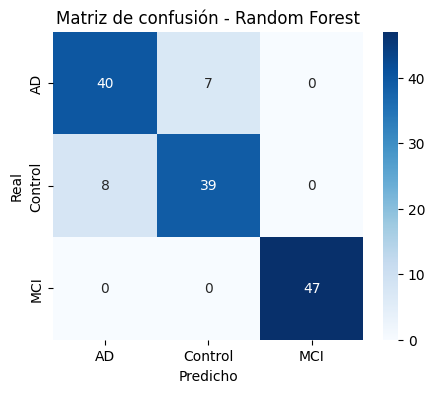


🔹 Entrenando XGBoost...

✅ Mejor configuración XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.833     0.851     0.842        47
     Control      0.884     0.809     0.844        47
         MCI      0.940     1.000     0.969        47

    accuracy                          0.887       141
   macro avg      0.886     0.887     0.885       141
weighted avg      0.886     0.887     0.885       141



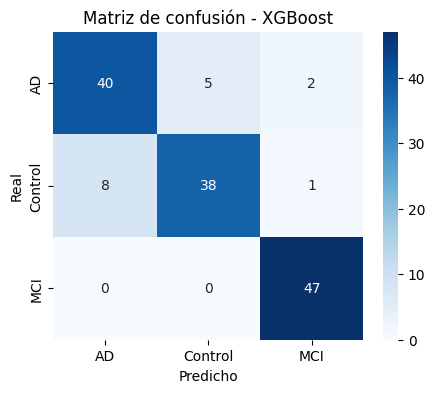


🔹 Entrenando Logistic Regression...

✅ Mejor configuración Logistic Regression: {'model__C': 10, 'tfidf__max_features': 3000}

              precision    recall  f1-score   support

          AD      0.854     0.872     0.863        47
     Control      0.860     0.787     0.822        47
         MCI      0.940     1.000     0.969        47

    accuracy                          0.887       141
   macro avg      0.885     0.887     0.885       141
weighted avg      0.885     0.887     0.885       141



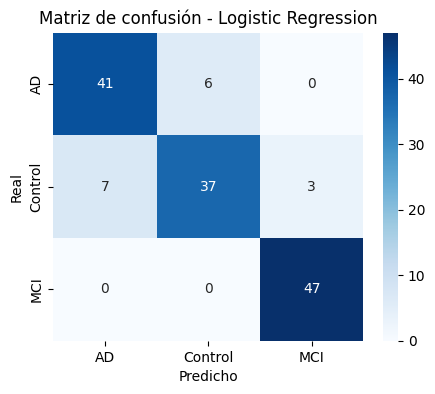

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils import shuffle
import seaborn as sns
import matplotlib.pyplot as plt

# ======================
# 🔹 1. Preparar dataset
# ======================
df = df.dropna(subset=['clean_transcripts', 'label'])
df = df[df['label'].isin(['Control', 'AD', 'MCI'])]

# 🔹 Codificar etiquetas a números
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['label'])
print("Mapeo de etiquetas:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_transcripts']
y = df['label_num']

# ======================
# 🔹 2. Oversampling (para balancear)
# ======================
oversampler = RandomOverSampler(random_state=42)
X_res, y_res = oversampler.fit_resample(X.values.reshape(-1, 1), y)
X_res = X_res.ravel()
X_res, y_res = shuffle(X_res, y_res, random_state=42)

print("Distribución después del oversampling:")
print(pd.Series(y_res).value_counts())

# ======================
# 🔹 3. Train/test split
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

# ======================
# 🔹 4. Modelos
# ======================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric='mlogloss'
    ),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

param_grids = {
    "Random Forest": {
        'tfidf__max_features': [3000],
        'model__n_estimators': [200],
        'model__max_depth': [10, 20, None]
    },
    "XGBoost": {
        'tfidf__max_features': [3000],
        'model__n_estimators': [300],
        'model__max_depth': [4, 6],
        'model__learning_rate': [0.05, 0.1]
    },
    "Logistic Regression": {
        'tfidf__max_features': [3000],
        'model__C': [0.1, 1, 10]
    }
}

# ======================
# 🔹 5. Entrenar y evaluar
# ======================
for name, model in models.items():
    print(f"\n🔹 Entrenando {name}...\n")

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english')),
        ('model', model)
    ])

    grid = GridSearchCV(pipeline, param_grids[name], cv=3, n_jobs=-1, scoring='f1_macro')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"✅ Mejor configuración {name}: {grid.best_params_}\n")
    print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

    # 📊 Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Matriz de confusión - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()
